# Project 2 — NLP | Step 1: Data Cleaning and Exploratory Data Analysis

**Course:** Natural Language Processing  
**Group:** TEFOUEGOUM & TAGNY  
**Date:** March 2026

---

## Objectives

In this first step, we explore and clean a dataset of customer reviews about insurance companies.  
The dataset is split across 14 Excel files that we will merge into a single DataFrame.

The main tasks are:

1. Load and merge all Excel files
2. Check for missing values, duplicates, and wrong data types
3. Clean the text (lowercase, punctuation, stopwords)
4. Visualize frequent words using word clouds and bar charts
5. Apply spelling correction
6. Save a clean CSV file ready for modeling

---

## Installing Required Libraries



In [ ]:
# Uncomment and run once if needed
"""
!pip install pandas numpy matplotlib seaborn wordcloud pyspellchecker nltk openpyxl
"""

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 71.7 MB/s eta 0:00:00


---
## 1 - Importing Libraries

In [ ]:
import os
import glob
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.util import ngrams
from collections import Counter

from wordcloud import WordCloud
from spellchecker import SpellChecker

# Download NLTK resources
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

print('success')

success


---
## 2 - Loading and Merging the Data

In [ ]:
# Update this path to match your local folder
FOLDER_PATH = r'Traduction avis clients'

# Find all Excel files in the folder
files = sorted(glob.glob(os.path.join(FOLDER_PATH, '*.xlsx')))
print(f'Number of files found: {len(files)}')
for f in files:
    print(f'  - {os.path.basename(f)}')

Number of files found: 35
  - avis_10_traduit.xlsx
  - avis_11_traduit.xlsx
  - avis_12_traduit.xlsx
  - avis_13_traduit.xlsx
  - avis_14_traduit.xlsx
  - avis_15_traduit.xlsx
  - avis_16_traduit.xlsx
  - avis_17_traduit.xlsx
  - avis_18_traduit.xlsx
  - avis_19_traduit.xlsx
  - avis_1_traduit.xlsx
  - avis_20_traduit.xlsx
  - avis_21_traduit.xlsx
  - avis_22_traduit.xlsx
  - avis_23_traduit.xlsx
  - avis_24_traduit.xlsx
  - avis_25_traduit.xlsx
  - avis_26_traduit.xlsx
  - avis_27_traduit.xlsx
  - avis_28_traduit.xlsx
  - avis_29_traduit.xlsx
  - avis_2_traduit.xlsx
  - avis_30_traduit.xlsx
  - avis_31_traduit.xlsx
  - avis_32_traduit.xlsx
  - avis_33_traduit.xlsx
  - avis_34_traduit.xlsx
  - avis_35_traduit.xlsx
  - avis_3_traduit.xlsx
  - avis_4_traduit.xlsx
  - avis_5_traduit.xlsx
  - avis_6_traduit.xlsx
  - avis_7_traduit.xlsx
  - avis_8_traduit.xlsx
  - avis_9_traduit.xlsx


In [ ]:
# Read and concatenate all files into one DataFrame.
# The loop catches errors file by file so one bad file does not stop everything.

all_dataframes = []
failed_files   = []

for file in files:
    try:
        temp_df = pd.read_excel(file)
        temp_df['source_file'] = os.path.basename(file)
        all_dataframes.append(temp_df)
        print(f"  loaded   {os.path.basename(file):40s}  ({len(temp_df):,} rows)")
    except PermissionError:
        print(f"  SKIPPED  {os.path.basename(file)} -- file is open in Excel, close it and re-run")
        failed_files.append(file)
    except Exception as e:
        print(f"  ERROR    {os.path.basename(file)} -- {e}")
        failed_files.append(file)

if failed_files:
    print(f"\nWarning: {len(failed_files)} file(s) could not be loaded:")
    for f in failed_files:
        print(f"  - {os.path.basename(f)}")
    print("Close those files in Excel and re-run this cell.")

if not all_dataframes:
    raise RuntimeError("No files were loaded. Check FOLDER_PATH and close all Excel files.")

df = pd.concat(all_dataframes, ignore_index=True)

print(f"\nFiles loaded : {len(all_dataframes)} / {len(files)}")
print(f"Total rows   : {df.shape[0]:,}")
print(f"Total columns: {df.shape[1]}")
df.head(3)

  loaded   avis_10_traduit.xlsx                      (1,000 rows)
  loaded   avis_11_traduit.xlsx                      (1,000 rows)
  loaded   avis_12_traduit.xlsx                      (1,000 rows)
  loaded   avis_13_traduit.xlsx                      (1,000 rows)
  loaded   avis_14_traduit.xlsx                      (1,000 rows)
  loaded   avis_15_traduit.xlsx                      (1,000 rows)
  loaded   avis_16_traduit.xlsx                      (1,000 rows)
  loaded   avis_17_traduit.xlsx                      (1,000 rows)
  loaded   avis_18_traduit.xlsx                      (1,000 rows)
  loaded   avis_19_traduit.xlsx                      (1,000 rows)
  loaded   avis_1_traduit.xlsx                       (1,000 rows)
  loaded   avis_20_traduit.xlsx                      (1,000 rows)
  loaded   avis_21_traduit.xlsx                      (1,000 rows)
  loaded   avis_22_traduit.xlsx                      (1,000 rows)
  loaded   avis_23_traduit.xlsx                      (1,000 rows)
  loaded  

,note,auteur,avis,assureur,produit,type,date_publication,date_exp,avis_en,avis_cor,avis_cor_en,source_file
0,4.0,audurier-c-136272,La personne au téléphone était Clair et sympat...,L'olivier Assurance,auto,train,06/10/2021,01/10/2021,The person on the phone was clear and friendly...,NaN,NaN,avis_10_traduit.xlsx
1,4.0,paul-a-122970,"Satisfait.\n\nRéactivité, simplicité. Prix att...",APRIL Moto,moto,train,09/07/2021,01/07/2021,"Satisfied.\n\nReactivity, simplicity. Attracti...",NaN,NaN,avis_10_traduit.xlsx
2,1.0,kitty-38517,"Assureur à fuir, n assure pas ses responsabili...",SwissLife,vie,train,15/10/2020,01/10/2020,"Insurer to flee, does not ensure its responsib...",NaN,NaN,avis_10_traduit.xlsx


---
## 3 - Initial Exploration

Before cleaning anything, we first inspect the data to understand its structure,  
identify problems, and plan the cleaning steps accordingly.

We check:
- Column names and data types
- Missing values per column
- Duplicate rows
- Distribution of the target variable (star ratings)

In [ ]:
# Column types
print(' Column Types ')
print(df.dtypes)

 Column Types 
note                float64
auteur               object
avis                 object
assureur             object
produit              object
type                 object
date_publication     object
date_exp             object
avis_en              object
avis_cor             object
avis_cor_en          object
source_file          object
dtype: object


In [ ]:
# Missing values as a percentage
print(' Missing Values (%) ')
missing_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
print(missing_pct[missing_pct > 0].round(2).to_string())

 Missing Values (%) 
avis_cor_en    98.75
avis_cor       98.74
note           30.00
avis_en         0.01
auteur          0.00


In [ ]:
# Duplicate rows
n_full_duplicates = df.duplicated().sum()
n_text_duplicates = df.duplicated(subset=['avis']).sum()

print(' Duplicates ')
print(f'Fully duplicated rows      : {n_full_duplicates}')
print(f'Rows with same review text : {n_text_duplicates}')

 Duplicates 
Fully duplicated rows      : 1
Rows with same review text : 58


In [ ]:
# Star rating distribution
print('Star Rating Distribution')
print(df['note'].value_counts().sort_index())

Star Rating Distribution
note
1.0    7271
2.0    3716
3.0    3382
4.0    4885
5.0    4850
Name: count, dtype: int64


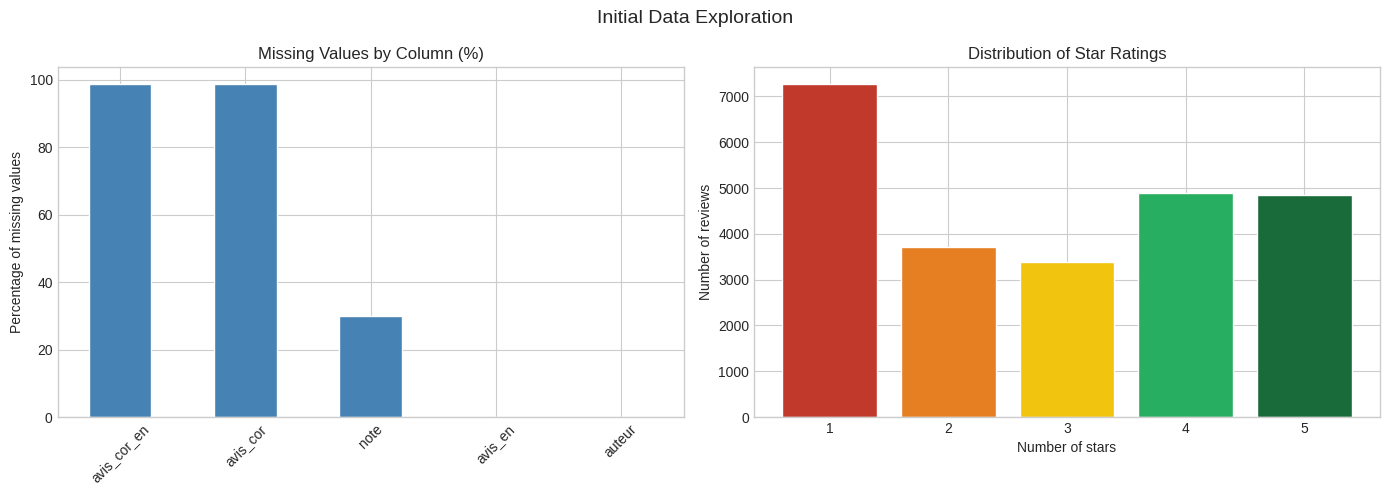

In [ ]:
# Visualize missing values and star rating distribution side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Missing values
missing_to_plot = missing_pct[missing_pct > 0]
if len(missing_to_plot) > 0:
    missing_to_plot.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
    axes[0].set_title('Missing Values by Column (%)')
    axes[0].set_ylabel('Percentage of missing values')
    axes[0].tick_params(axis='x', rotation=45)
else:
    axes[0].text(0.5, 0.5, 'No missing values found.',
                 ha='center', va='center', fontsize=13, transform=axes[0].transAxes)
    axes[0].set_title('Missing Values')

# Plot 2: Star rating distribution
star_counts = df['note'].value_counts().sort_index()
axes[1].bar(star_counts.index, star_counts.values,
            color=['#c0392b', '#e67e22', '#f1c40f', '#27ae60', '#1a6b3a'],
            edgecolor='white')
axes[1].set_title('Distribution of Star Ratings')
axes[1].set_xlabel('Number of stars')
axes[1].set_ylabel('Number of reviews')
axes[1].set_xticks([1, 2, 3, 4, 5])

plt.suptitle('Initial Data Exploration', fontsize=14)
plt.tight_layout()
plt.savefig('Traduction avis clients/Traduction avis clients graphiques/01_initial_exploration.png', dpi=150, bbox_inches='tight')
plt.show()

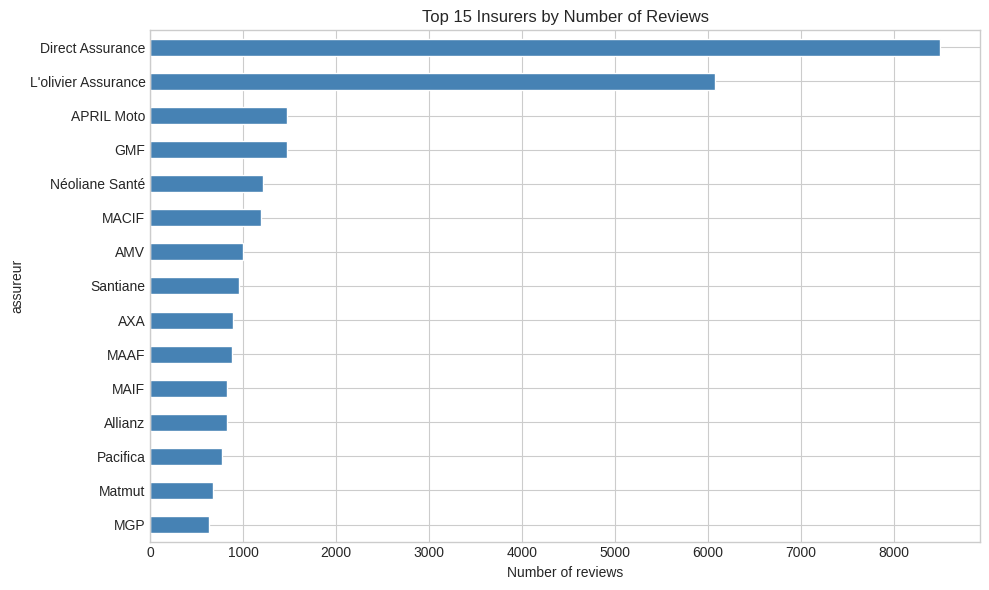

 Average Rating per Insurer (Top 10 by volume) 
                     average  count
assureur                           
Direct Assurance        3.31   5896
L'olivier Assurance     3.83   4288
APRIL Moto              3.95   1023
GMF                     2.89    997
Néoliane Santé          2.80    861
MACIF                   1.81    829
AMV                     3.69    688
Santiane                3.47    658
AXA                     1.70    629
MAAF                    1.85    612


In [ ]:
# Number of reviews per insurer (top 15)
fig, ax = plt.subplots(figsize=(10, 6))
top_insurers = df['assureur'].value_counts().head(15)
top_insurers.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Top 15 Insurers by Number of Reviews')
ax.set_xlabel('Number of reviews')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('Traduction avis clients/Traduction avis clients graphiques/02_reviews_per_insurer.png', dpi=150, bbox_inches='tight')
plt.show()

# Average rating per insurer
print(' Average Rating per Insurer (Top 10 by volume) ')
print(
    df.groupby('assureur')['note']
    .agg(average='mean', count='count')
    .sort_values('count', ascending=False)
    .head(10)
    .round(2)
)

---
## 4  Data Cleaning

### 4.1 Removing Duplicates and Handling Missing Values

We remove:
- Fully duplicated rows
- Rows where the review text appears more than once (keeping the first occurrence)
- Rows with no review text or no rating

 -------------------------------------------------------------------
 CRITICAL OBSERVATIONS BEFORE CLEANING
 -------------------------------------------------------------------
 1. avis_cor and avis_cor_en are ~99% empty -> we use avis_en as main text source
 2. note has 30% missing values -> likely the test split has no labels
    we keep those rows for prediction later but exclude from training
 3. note is float64 -> we convert to Int64 (nullable integer) to preserve NaN rows
 4. dates are stored as strings -> we convert to datetime
 -------------------------------------------------------------------


In [ ]:

print(f"Shape before cleaning: {df.shape}")

# Step 1: remove fully duplicated rows
df = df.drop_duplicates()
print(f"After removing full duplicates       : {df.shape}")

# Step 2: remove rows where review text is missing (no text = useless)
df = df.dropna(subset=['avis'])
print(f"After removing empty reviews         : {df.shape}")

# Step 3: remove rows with duplicate review text, keep first occurrence
df = df.drop_duplicates(subset=['avis'], keep='first')
print(f"After removing duplicate review text : {df.shape}")

# Step 4: convert note to numeric
# We do NOT drop NaN notes yet -- these are likely the test rows without labels
df['note'] = pd.to_numeric(df['note'], errors='coerce')

# Separate train (has note) and test (no note) for clarity
df_train = df[df['note'].notna()].copy()
df_test  = df[df['note'].isna()].copy()

df_train['note'] = df_train['note'].astype(int)

print(f"\nRows with a rating (train) : {len(df_train):,}")
print(f"Rows without rating (test) : {len(df_test):,}")

# Check: are missing notes explained by the type column?
print("\nMissing note breakdown by type:")
print(df.groupby('type', dropna=False)['note'].apply(lambda x: x.isna().sum()))

# Step 5: convert date columns to datetime
for col in ['date_publication', 'date_exp']:
    if col in df_train.columns:
        df_train[col] = pd.to_datetime(df_train[col], dayfirst=True, errors='coerce')


Shape before cleaning: (34435, 12)
After removing full duplicates       : (34434, 12)
After removing empty reviews         : (34434, 12)
After removing duplicate review text : (34377, 12)

Rows with a rating (train) : 24,067
Rows without rating (test) : 10,310

Missing note breakdown by type:
type
test     10310
train        0
Name: note, dtype: int64


### 4.2 Creating a Sentiment Label

We create a new column `sentiment` based on the star rating:

| Stars | Sentiment |
|-------|-----------|
| 1 - 2 | negative  |
| 3     | neutral   |
| 4 - 5 | positive  |

In [ ]:
def assign_sentiment(rating):
    if rating <= 2:
        return 'negative'
    elif rating == 3:
        return 'neutral'
    else:
        return 'positive'

df_train['sentiment'] = df_train['note'].apply(assign_sentiment)

# Step 7: select best available text source
# avis_cor_en is 99% empty so we fall back to avis_en, then avis
def select_text_source(row):
    for col in ['avis_en', 'avis']:
        if pd.notna(row.get(col)) and str(row.get(col)).strip() != '':
            return str(row[col])
    return ''

df_train['text_source'] = df_train.apply(select_text_source, axis=1)

df_train = df_train.reset_index(drop=True)

print(f"\nFinal train dataset: {len(df_train):,} rows")
print(f"Sentiment distribution:")
print(df_train['sentiment'].value_counts())


Final train dataset: 24,067 rows
Sentiment distribution:
sentiment
negative    10961
positive     9727
neutral      3379
Name: count, dtype: int64


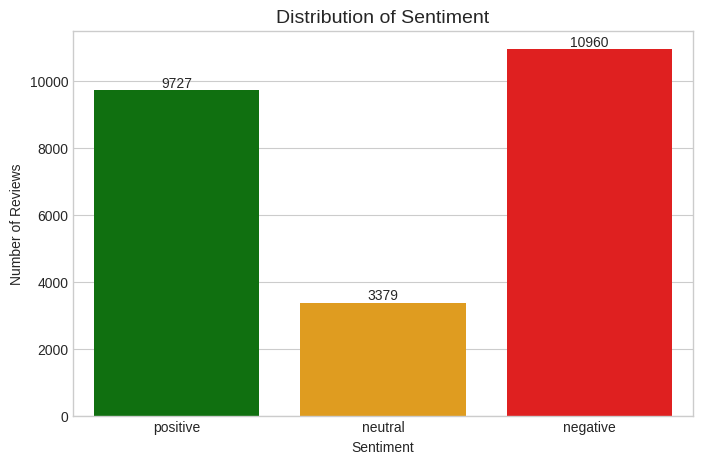

In [ ]:
couleurs = {
    "negative": "red",
    "neutral": "orange",
    "positive": "green"
}
order = ["positive", "neutral", "negative"]

plt.figure(figsize=(8,5))
ax = sns.countplot(x='sentiment', data=df_train, palette=couleurs, order=order)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom')

plt.title("Distribution of Sentiment", fontsize=14)
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

plt.show()

### 4.3 Text Cleaning

We create a cleaned version of the review text.  
The column `avis_cor_en` already contains translated and partially corrected English text,  
so we use it as our main text source.

Cleaning steps applied:
1. Lowercase everything
2. Remove URLs
3. Remove punctuation
4. Remove isolated numbers
5. Remove stopwords (English and French combined)
6. Remove very short tokens (less than 3 characters)

In [ ]:
# Build a combined stopword list
stop_english = set(stopwords.words('english'))
stop_french  = set(stopwords.words('french'))
domain_stops = {'insurance', 'insurer', 'assurance', 'assureur',
                'also', 'one', 'get', 'year', 'years'}

all_stopwords = stop_english | stop_french | domain_stops


def clean_text(text):
    if pd.isna(text) or str(text).strip() == '':
        return ''
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)   # Remove URLs
    text = re.sub(r'[^\w\s]', ' ', text)         # Remove punctuation
    text = re.sub(r'\b\d+\b', '', text)          # Remove isolated numbers
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in all_stopwords and len(t) > 2]
    return ' '.join(tokens)


def select_text_source(row):
    # Use the best available translated/corrected column
    for col in ['avis_cor_en', 'avis_en', 'avis']:
        if col in row.index and pd.notna(row[col]) and str(row[col]).strip() != '':
            return str(row[col])
    return ''


df['text_source'] = df.apply(select_text_source, axis=1)
df['text_clean']  = df['text_source'].apply(clean_text)

print('Cleaning example:')
print('Before:', df['text_source'].iloc[0][:120])
print('After :', df['text_clean'].iloc[0][:120])

Cleaning example:
Before: The person on the phone was clear and friendly she explained everything to me I would recommend your insurance without h
After : person phone clear friendly explained everything would recommend without hesitation thank person contacted


In [ ]:
# Apply text cleaning to the train set
df_train['text_clean'] = df_train['text_source'].apply(clean_text)

# Quick check
print(f"text_clean created: {df_train['text_clean'].notna().sum():,} values")
print(f"Empty after cleaning: {(df_train['text_clean'] == '').sum()} rows")
print()
print("Before:", df_train['text_source'].iloc[0][:120])
print("After :", df_train['text_clean'].iloc[0][:120])

text_clean created: 24,067 values
Empty after cleaning: 1 rows

Before: The person on the phone was clear and friendly she explained everything to me I would recommend your insurance without h
After : person phone clear friendly explained everything would recommend without hesitation thank person contacted


In [ ]:
# Inspect the review that became empty after cleaning
empty_mask = df_train['text_clean'] == ''
print(df_train.loc[empty_mask, ['note', 'sentiment', 'avis', 'text_source']])

       note sentiment                           avis              text_source
15015     1  negative  assureur qui n'en est pas un.  insurer who is not one.


In [ ]:
# Remove the one review that became empty after cleaning
# This review was "insurer who is not one." -- all tokens were stopwords or domain stops
# Keeping an empty string would cause errors in vectorization and embedding steps

before = len(df_train)
df_train = df_train[df_train['text_clean'] != ''].reset_index(drop=True)

print(f"Rows removed : {before - len(df_train)}")
print(f"Train set final size : {len(df_train):,}")

Rows removed : 1
Train set final size : 24,066


### Note on Empty Reviews After Cleaning

One review became empty after text cleaning:
- Original (French): "assureur qui n'en est pas un."
- Translated: "insurer who is not one."
- All tokens were either stopwords or domain-specific stop words ("insurer").

This is a known limitation of aggressive stopword removal: very short reviews
that express a clear opinion through negation or implicit meaning can lose
all their content during preprocessing.

This row was removed from the train set. It will be cited in the error analysis
in Week 2 as an example of a review that is humanly interpretable but
computationally empty after standard NLP preprocessing.

---
##  5  Word Frequency Visualization

### 5.1 Word Clouds

A word cloud shows the most frequent words in the corpus.  
The larger the word, the more often it appears in the reviews.  
We generate three word clouds: one for all reviews, one for positive reviews, and one for negative reviews.

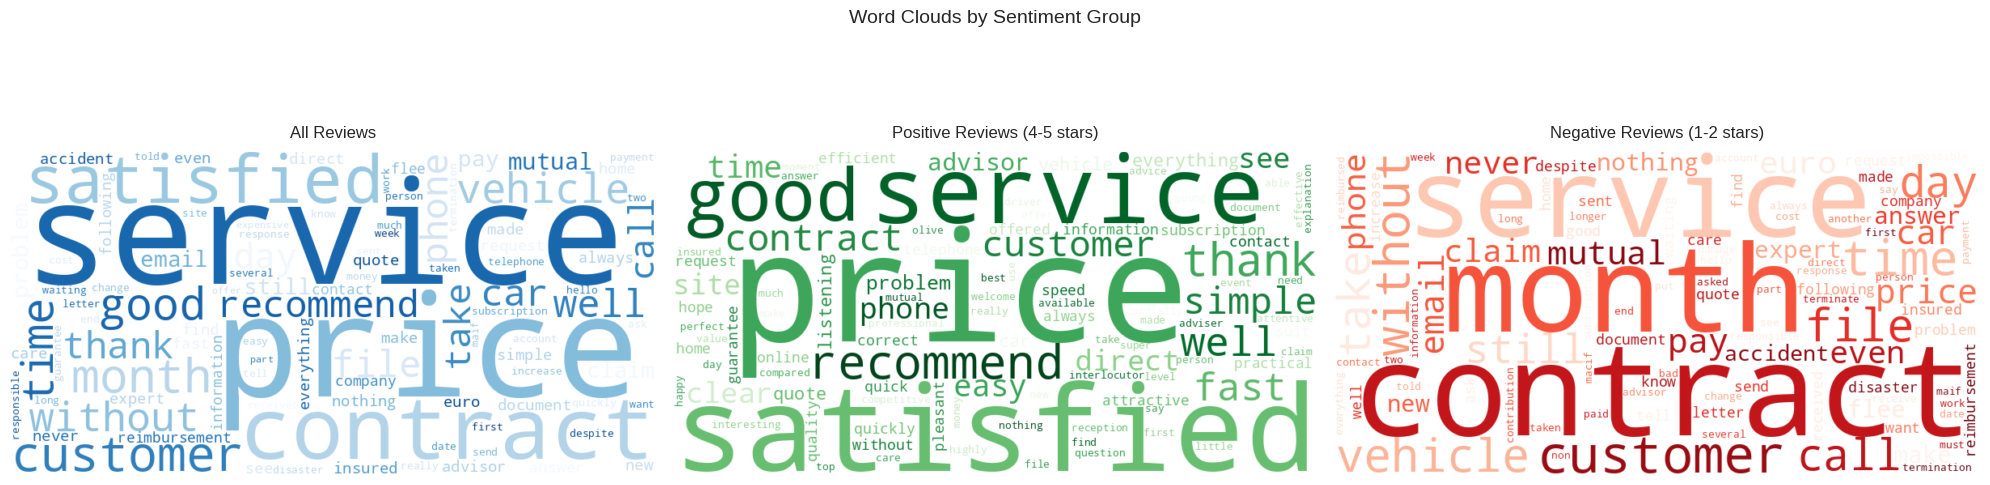

In [ ]:
def generate_wordcloud(text_series, ax, title, colormap='Blues'):
    combined_text = ' '.join(text_series.dropna().tolist())
    wc = WordCloud(
        width=800,
        height=400,
        background_color='white',
        colormap=colormap,
        max_words=100,
        collocations=False
    ).generate(combined_text)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(title, fontsize=12, pad=10)


fig, axes = plt.subplots(1, 3, figsize=(20, 6))

generate_wordcloud(df_train['text_clean'],
                   axes[0], 'All Reviews', colormap='Blues')
generate_wordcloud(df_train.loc[df_train['sentiment'] == 'positive', 'text_clean'],
                   axes[1], 'Positive Reviews (4-5 stars)', colormap='Greens')
generate_wordcloud(df_train.loc[df_train['sentiment'] == 'negative', 'text_clean'],
                   axes[2], 'Negative Reviews (1-2 stars)', colormap='Reds')

plt.suptitle('Word Clouds by Sentiment Group', fontsize=14)
plt.tight_layout()
plt.savefig('Traduction avis clients/Traduction avis clients graphiques/04_wordclouds.png', dpi=150, bbox_inches='tight')
plt.show()

### Observations on Word Clouds

The word clouds reveal the main themes across the corpus:

- **Across all reviews:** service, contract, price, and customer dominate.
  These are the expected central topics for insurance reviews.

- **Positive reviews:** satisfied, recommend, efficient, simple, and good price
  are the most prominent. Customers who are happy tend to highlight
  the quality-price ratio and ease of use.

- **Negative reviews:** contract, file, claim, month, and vehicle stand out.
  The vocabulary shifts from satisfaction to procedural complaints --
  delayed claims, contract issues, and billing problems.

**Key limitation of word clouds:** the words `price` and `service` appear
prominently in all three groups. A single word carries no sentiment on its own --
"good price" and "price increase" look identical at the unigram level.
This confirms that bag-of-words approaches will have limited discriminative power,
and that bigrams, embeddings, and contextual models will be necessary
to capture the actual meaning of these reviews.

### 5.2 Top N-grams

An N-gram is a sequence of N consecutive words.  
- **Unigram** (1 word): e.g. "price", "service"  
- **Bigram** (2 words): e.g. "customer service", "claim process"  
- **Trigram** (3 words): e.g. "good customer service"

N-grams give us more context than individual words and help identify recurring themes in the reviews.

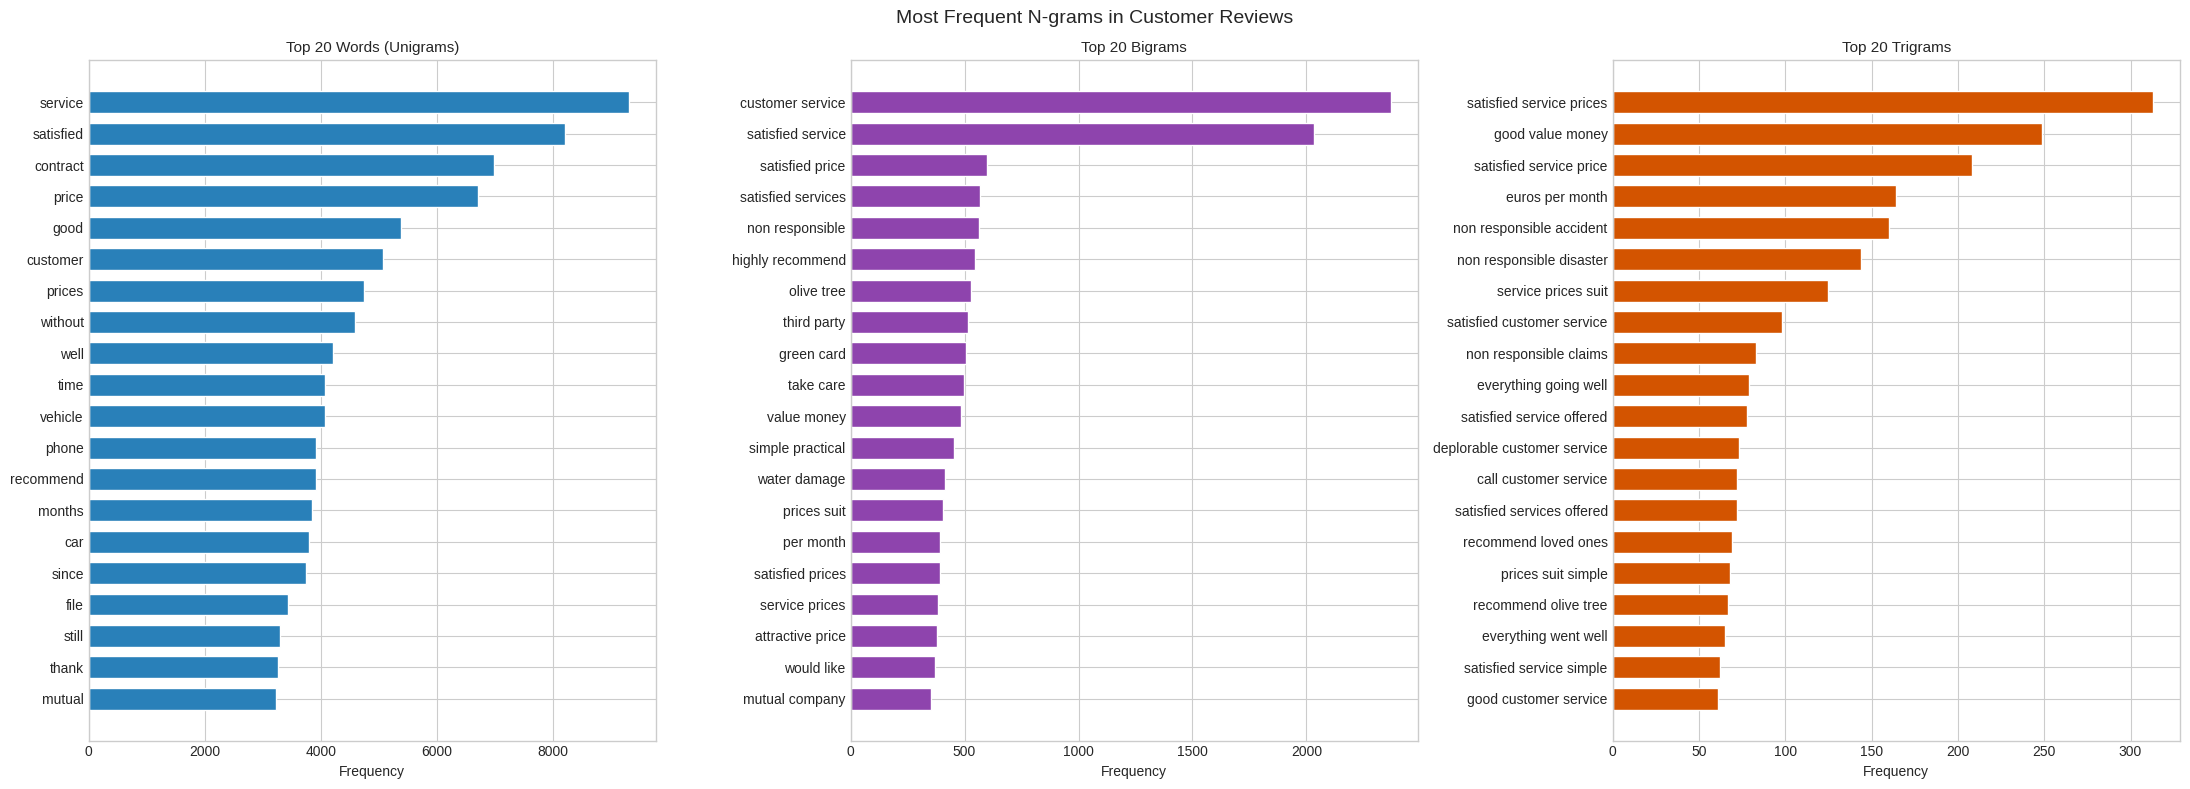

In [ ]:
def get_top_ngrams(text_series, n, top_k=20):
    all_ngrams = []
    for text in text_series.dropna():
        tokens = text.split()
        all_ngrams.extend(list(ngrams(tokens, n)))
    counts = Counter(all_ngrams).most_common(top_k)
    labels = [' '.join(gram) for gram, _ in counts]
    values = [count for _, count in counts]
    return labels, values


def plot_ngrams(ax, labels, values, title, color):
    ax.barh(list(reversed(labels)), list(reversed(values)),
            color=color, edgecolor='white', height=0.7)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Frequency')


fig, axes = plt.subplots(1, 3, figsize=(22, 8))

labels1, values1 = get_top_ngrams(df['text_clean'], n=1)
plot_ngrams(axes[0], labels1, values1, 'Top 20 Words (Unigrams)', '#2980b9')

labels2, values2 = get_top_ngrams(df['text_clean'], n=2)
plot_ngrams(axes[1], labels2, values2, 'Top 20 Bigrams', '#8e44ad')

labels3, values3 = get_top_ngrams(df['text_clean'], n=3)
plot_ngrams(axes[2], labels3, values3, 'Top 20 Trigrams', '#d35400')

plt.suptitle('Most Frequent N-grams in Customer Reviews', fontsize=14)
plt.tight_layout()
plt.savefig('Traduction avis clients/Traduction avis clients graphiques/05_ngrams.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6  Spelling Correction

We use the `pyspellchecker` library to detect and correct spelling mistakes in the English reviews.  
The library compares each word to a known English dictionary.  
If a word is not recognized, it suggests the closest valid word.

Since the column `avis_cor_en` already contains a corrected and translated version of the reviews,  
we first check whether it is sufficiently populated before deciding to re-apply the spell checker.

In [ ]:
spell_checker = SpellChecker(language='en')


def correct_spelling(text, max_words=60):
    """
    Corrects spelling mistakes in a string.
    We process only the first max_words words to keep the function fast.
    """
    if pd.isna(text) or str(text).strip() == '':
        return text

    words = str(text).split()
    words_to_check = words[:max_words]
    misspelled = spell_checker.unknown(words_to_check)

    corrected = []
    for word in words_to_check:
        if word.lower() in misspelled:
            suggestion = spell_checker.correction(word)
            corrected.append(suggestion if suggestion else word)
        else:
            corrected.append(word)

    return ' '.join(corrected + words[max_words:])


# Show examples before applying to the full dataset
print('Spelling correction examples:')
print('-' * 60)
for i, text in enumerate(df['avis_en'].dropna().head(3)):
    corrected = correct_spelling(text)
    print(f'[{i+1}] Before: {text[:100]}')
    print(f'     After : {corrected[:100]}')
    print()

Spelling correction examples:
------------------------------------------------------------
[1] Before: The person on the phone was clear and friendly she explained everything to me I would recommend your
     After : The person on the phone was clear and friendly she explained everything to me I would recommend your

[2] Before: Satisfied.

Reactivity, simplicity. Attractive price from a competition point of view. To see the re
     After : satisfied reactivity simplicity Attractive price from a competition point of view To see the respons

[3] Before: Insurer to flee, does not ensure its responsibilities! His insurance agent (SLR FINANCE) from Nice t
     After : Insurer to fleet does not ensure its responsibilities His insurance agent sir finance from Nice to m



In [ ]:
# Coverage already measured in Section 3: avis_cor_en is 98.75% empty.
# Spell correction is also discarded after manual inspection (see markdown above).
# We simply assign text_source as the final text column.

df_train['avis_spell_corrected'] = df_train['text_source']
print(f"avis_spell_corrected created: {df_train['avis_spell_corrected'].notna().sum():,} values")

avis_spell_corrected created: 24,066 values


---
## Section 7 — Saving the Clean Dataset

We select the most relevant columns and save the final dataset as a CSV file.  
This file will be used as the starting point for all subsequent steps (topic modeling, embeddings, supervised learning).

**Columns in the output file:**

| Column | Description |
|--------|-------------|
| `note` | Star rating (1 to 5) — regression target |
| `sentiment` | Sentiment label (positive / neutral / negative) — classification target |
| `auteur` | Author identifier |
| `assureur` | Insurance company name |
| `produit` | Product type (auto, moto, sante, ...) |
| `type` | Train / test split |
| `avis` | Original review in French |
| `avis_cor` | Corrected French review |
| `avis_en` | Raw English translation |
| `avis_cor_en` | Corrected English translation |
| `avis_spell_corrected` | Final spell-corrected text |
| `text_clean` | Fully cleaned text ready for NLP modeling |

In [ ]:
columns_to_keep = [
    'note',
    'sentiment',
    'auteur',
    'assureur',
    'produit',
    'type',
    'avis',
    'avis_en',
    'avis_spell_corrected',
    'text_clean',
]

# Keep only columns that exist
columns_final = [c for c in columns_to_keep if c in df_train.columns]
df_clean = df_train[columns_final].copy()

output_path = 'Traduction avis clients/Traduction avis clients graphiques/insurance_reviews_clean.csv'
df_clean.to_csv(output_path, index=False, encoding='utf-8')

print(f"Saved to             : {output_path}")
print(f"Shape                : {df_clean.shape[0]:,} rows x {df_clean.shape[1]} columns")
print(f"Columns saved        : {list(df_clean.columns)}")
print(f"\nSentiment breakdown  :")
print(df_clean['sentiment'].value_counts())
df_clean.head(3)

Saved to             : Traduction avis clients/Traduction avis clients graphiques/insurance_reviews_clean.csv
Shape                : 24,066 rows x 10 columns
Columns saved        : ['note', 'sentiment', 'auteur', 'assureur', 'produit', 'type', 'avis', 'avis_en', 'avis_spell_corrected', 'text_clean']

Sentiment breakdown  :
sentiment
negative    10960
positive     9727
neutral      3379
Name: count, dtype: int64


,note,sentiment,auteur,assureur,produit,type,avis,avis_en,avis_spell_corrected,text_clean
0,4,positive,audurier-c-136272,L'olivier Assurance,auto,train,La personne au téléphone était Clair et sympat...,The person on the phone was clear and friendly...,The person on the phone was clear and friendly...,person phone clear friendly explained everythi...
1,4,positive,paul-a-122970,APRIL Moto,moto,train,"Satisfait.\n\nRéactivité, simplicité. Prix att...","Satisfied.\n\nReactivity, simplicity. Attracti...","Satisfied.\n\nReactivity, simplicity. Attracti...",satisfied reactivity simplicity attractive pri...
2,1,negative,kitty-38517,SwissLife,vie,train,"Assureur à fuir, n assure pas ses responsabili...","Insurer to flee, does not ensure its responsib...","Insurer to flee, does not ensure its responsib...",flee ensure responsibilities agent slr finance...
